# 09 — + Centroid Inference (Last Hidden Layer)

Builds on **07 +Centroid(Last)**: enables CentroidProjection during inference.
At eval time (when no labels are provided), each sample is assigned to its
nearest centroid via `torch.cdist`, then nudged using those assignments.

**Cumulative stack:** L2 + BN + LN + Dropout + L1 + Centroid(last, infer)

**What to look for:**
- Compare embeddings at eval time vs 07 — inference projection should tighten clusters
- Check whether nearest-centroid assignment is accurate enough to help
- Centroids are still computed globally at the start of each epoch

In [1]:
import sys
import os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

from scripts.viz_export import ExperimentTracker
import numpy as np
from sklearn.metrics import silhouette_score

torch.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"PyTorch {torch.__version__}")
device = torch.device("cpu")

/Users/morgancooper/miniconda3/envs/nnpo/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch 2.10.0


## 1. Load MNIST

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
    transforms.Lambda(lambda x: x.view(-1)),
])

data_root = os.path.join(PROJECT_ROOT, "data")
full_train_dataset = datasets.MNIST(root=data_root, train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root=data_root, train=False, download=True, transform=transform)

train_dataset, val_dataset = random_split(
    full_train_dataset, [48000, 12000],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True, generator=torch.Generator().manual_seed(0))
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 48000, Val: 12000, Test: 10000


## 2. Define Model

In [3]:
PROJ_ALPHA = 0.3
PROJ_BETA = 0.1
PROJ_INFER = True

class CentroidProjection(nn.Module):
    """Directly manipulates activations: repel from other centroids, condense toward own.

    Centroids are computed globally after each epoch by calling update_centroids(),
    then used as fixed targets during the next epoch's forward passes.
    Straight-through for gradients (applied in forward, invisible to backward).

    When infer=True and labels are not provided (eval mode), assigns each sample
    to its nearest centroid via torch.cdist and uses those as pseudo-labels.
    """
    def __init__(self, dim, num_classes=10, alpha=0.1, beta=0.05, infer=False):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.num_classes = num_classes
        self.infer = infer
        self.register_buffer('centroids', torch.zeros(num_classes, dim))
        self.register_buffer('ready', torch.tensor(False))

    def update_centroids(self, centroids):
        """Set centroids from a pre-computed [num_classes, dim] tensor."""
        self.centroids.copy_(centroids)
        self.ready.fill_(True)

    def forward(self, x, labels=None):
        if not self.ready:
            return x

        # At inference: assign nearest centroid as pseudo-label
        if labels is None:
            if not self.infer:
                return x
            with torch.no_grad():
                dists = torch.cdist(x, self.centroids)  # [batch, num_classes]
                labels = dists.argmin(dim=1)             # [batch]

        with torch.no_grad():
            repulsion = torch.zeros_like(self.centroids)
            for c in range(self.num_classes):
                others = [i for i in range(self.num_classes) if i != c]
                diffs = self.centroids[c] - self.centroids[others]
                dists = diffs.norm(dim=1, keepdim=True).clamp(min=1e-6)
                repulsion[c] = (diffs / dists ** 2).sum(dim=0)

            rep_norms = repulsion.norm(dim=1, keepdim=True).clamp(min=1e-6)
            repulsion = repulsion / rep_norms * self.beta
            nudge = repulsion[labels]

            diff = self.centroids[labels] - x
            dist = diff.norm(dim=1, keepdim=True).clamp(min=1e-6)
            mean_dist = dist.mean()
            scale = dist / (mean_dist + 1e-8)
            nudge = nudge + self.alpha * scale * diff

        return x + nudge

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.drop1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 64)
        self.ln2 = nn.LayerNorm(64)
        self.drop2 = nn.Dropout(0.3)
        self.proj = CentroidProjection(64, num_classes=10, alpha=PROJ_ALPHA, beta=PROJ_BETA, infer=PROJ_INFER)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x, labels=None):
        x = self.drop1(torch.relu(self.bn1(self.fc1(x))))
        x = self.drop2(torch.relu(self.ln2(self.fc2(x))))
        x = self.proj(x, labels)
        x = self.fc3(x)
        return x

    def compute_centroids(self, loader, device):
        """Forward pass over full dataset to compute per-class mean activations at hidden_2."""
        self.eval()
        sums = torch.zeros(10, 64, device=device)
        counts = torch.zeros(10, device=device)
        with torch.no_grad():
            for batch_x, batch_y in loader:
                batch_x = batch_x.to(device)
                h = torch.relu(self.ln2(self.fc2(self.drop1(torch.relu(self.bn1(self.fc1(batch_x)))))))
                for c in range(10):
                    mask = (batch_y == c)
                    if mask.any():
                        sums[c] += h[mask].sum(dim=0)
                        counts[c] += mask.sum()
        centroids = sums / counts.unsqueeze(1).clamp(min=1)
        return centroids

model = MLP().to(device)
print(f"CentroidProjection: alpha={PROJ_ALPHA}, beta={PROJ_BETA}, infer={PROJ_INFER}")
print(model)

CentroidProjection: alpha=0.3, beta=0.1, infer=True
MLP(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (drop2): Dropout(p=0.3, inplace=False)
  (proj): CentroidProjection()
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)


## 3. Pick Input Samples & Viz Samples

In [4]:
# 5 input samples: one per distinct digit (first 5 unique)
seen_labels = set()
five_images, five_labels = [], []
for img, label in full_train_dataset:
    if label not in seen_labels:
        five_images.append(img)
        five_labels.append(int(label))
        seen_labels.add(label)
    if len(seen_labels) == 5:
        break
five_images = torch.stack(five_images)
print(f"Input samples: labels={five_labels}, shape={five_images.shape}")

# 500 viz samples: 50 per class
viz_images, viz_labels = [], []
class_counts = {c: 0 for c in range(10)}
for img, label in full_train_dataset:
    label = int(label)
    if class_counts[label] < 50:
        viz_images.append(img)
        viz_labels.append(label)
        class_counts[label] += 1
    if all(v >= 50 for v in class_counts.values()):
        break
viz_images = torch.stack(viz_images)
print(f"Viz samples: {len(viz_labels)} total, shape={viz_images.shape}")

Input samples: labels=[5, 0, 4, 1, 9], shape=torch.Size([5, 784])
Viz samples: 500 total, shape=torch.Size([500, 784])


## 4. Create Tracker

In [5]:
tracker = ExperimentTracker(
    run_id="mnist_centroid_infer_last",
    model_name="MNIST +Centroid(Last, Infer)",
    description="All standard + CentroidProjection on hidden_2 with inference",
    hyperparameters={
        "lr": 0.001, "batch_size": 512, "epochs": 10,
        "weight_decay": 1e-4, "l1_lambda": 1e-4, "dropout": 0.3,
        "proj_alpha": PROJ_ALPHA, "proj_beta": PROJ_BETA,
        "proj_infer": PROJ_INFER,
    },
    model=model,
)

tracker.track("input", size=784)
tracker.track("hidden_1", model.fc1, size=128)
tracker.track("hidden_2", model.fc2, size=64)
tracker.track("projected", model.proj, size=64)
tracker.track("output", model.fc3, size=10)

tracker.set_input_samples(five_images, five_labels)
tracker.set_viz_samples(viz_images, viz_labels)
tracker.enable_gradient_capture()
tracker.enable_forward_labels()
tracker.enable_loss_landscape()

ExperimentTracker: will write to /Users/morgancooper/NeuralNetworkProjectionOperator/scripts/../experimentation/runs/mnist_centroid_infer_last_v2


## 5. Train

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
l1_lambda = 1e-4

CHECKPOINT_EVERY = 10
num_epochs = 5

def evaluate(loader):
    model.eval()
    total_loss = correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            out = model(x)
            total_loss += criterion(out, y).item() * y.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
    return total_loss / total, correct / total

# Training history for plotting
history = {"epoch": [], "train_loss": [], "val_loss": [], "val_accuracy": [], "test_accuracy": []}

step = 0
global_batch = 0

for epoch in range(num_epochs):
    centroids = model.compute_centroids(train_loader, device)
    model.proj.update_centroids(centroids)
    print(f"Epoch {epoch}: centroids updated from full dataset")

    model.train()
    running_loss = 0.0

    for batch_idx, (batch_x, batch_y) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(batch_x, labels=batch_y)
        l1_norm = sum(p.abs().sum() for p in model.parameters())
        loss = criterion(output, batch_y) + l1_lambda * l1_norm
        loss.backward()
        tracker.capture_gradients()
        optimizer.step()
        running_loss += loss.item()
        global_batch += 1
        if global_batch % CHECKPOINT_EVERY == 0:
            val_loss, val_acc = evaluate(val_loader)
            _, test_acc = evaluate(test_loader)
            tracker.compute_loss_landscape(batch_x, batch_y, criterion)
            tracker.save_checkpoint(step=step, epoch=epoch, metrics={
                "train_loss": running_loss / (batch_idx + 1),
                "val_loss": val_loss,
                "val_accuracy": val_acc,
                "test_accuracy": test_acc,
            })
            step += 1
            model.train()

    print(f"Epoch {epoch}: loss={running_loss / len(train_loader):.4f}")

    # Record epoch metrics
    val_loss, val_acc = evaluate(val_loader)
    _, test_acc = evaluate(test_loader)
    history["epoch"].append(epoch)
    history["train_loss"].append(running_loss / len(train_loader))
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)
    history["test_accuracy"].append(test_acc)

print()
print(f"Total checkpoints saved: {step}")

Epoch 0: centroids updated from full dataset
  step_000.json (epoch=0, loss=1.5005, acc=0.7976, size=5.0MB)
  step_001.json (epoch=0, loss=1.2058, acc=0.8515, size=5.1MB)
  step_002.json (epoch=0, loss=0.9918, acc=0.8724, size=5.1MB)
  step_003.json (epoch=0, loss=0.8296, acc=0.8867, size=5.1MB)
  step_004.json (epoch=0, loss=0.6923, acc=0.8974, size=5.1MB)
  step_005.json (epoch=0, loss=0.5914, acc=0.9031, size=5.1MB)
  step_006.json (epoch=0, loss=0.5126, acc=0.9083, size=5.1MB)
  step_007.json (epoch=0, loss=0.4498, acc=0.9148, size=5.1MB)
  step_008.json (epoch=0, loss=0.4033, acc=0.9168, size=5.1MB)
Epoch 0: loss=1.1596
Epoch 1: centroids updated from full dataset
  step_009.json (epoch=1, loss=0.3529, acc=0.9209, size=5.1MB)
  step_010.json (epoch=1, loss=0.3410, acc=0.9234, size=5.1MB)
  step_011.json (epoch=1, loss=0.3307, acc=0.9258, size=5.1MB)
  step_012.json (epoch=1, loss=0.3239, acc=0.9274, size=5.1MB)
  step_013.json (epoch=1, loss=0.3161, acc=0.9299, size=5.1MB)
  step_

## 6. Training Curves

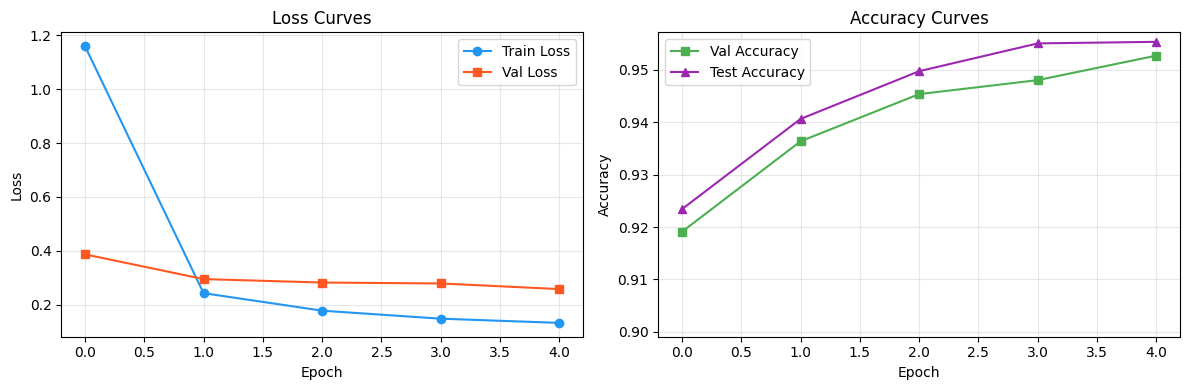

Epoch  Train Loss  Val Loss  Val Acc  Test Acc
-----------------------------------------------
    0      1.1596    0.3871   0.9191    0.9234
    1      0.2432    0.2954   0.9363    0.9406
    2      0.1781    0.2825   0.9453    0.9497
    3      0.1484    0.2791   0.9480    0.9550
    4      0.1328    0.2582   0.9527    0.9553


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = history["epoch"]

# --- Loss ---
ax = axes[0]
ax.plot(epochs, history["train_loss"], "o-", label="Train Loss", color="#2196F3")
ax.plot(epochs, history["val_loss"], "s-", label="Val Loss", color="#FF5722")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Loss Curves")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Accuracy ---
ax = axes[1]
ax.plot(epochs, history["val_accuracy"], "s-", label="Val Accuracy", color="#4CAF50")
ax.plot(epochs, history["test_accuracy"], "^-", label="Test Accuracy", color="#9C27B0")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy Curves")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=max(0, min(history["val_accuracy"]) - 0.02))

plt.tight_layout()
plt.show()

# Summary table
print(f"{'Epoch':>5} {'Train Loss':>11} {'Val Loss':>9} {'Val Acc':>8} {'Test Acc':>9}")
print("-" * 47)
for i, ep in enumerate(epochs):
    print(f"{ep:>5d} {history['train_loss'][i]:>11.4f} {history['val_loss'][i]:>9.4f} "
          f"{history['val_accuracy'][i]:>8.4f} {history['test_accuracy'][i]:>9.4f}")

## 7. Finalize

In [8]:
tracker.finalize()
print(f"Run directory: {tracker.run_dir}")
print(f"Run ID: {tracker.run_id}")

# Final evaluation
val_loss, val_acc = evaluate(val_loader)
test_loss, test_acc = evaluate(test_loader)
print(f"\nFinal val accuracy:  {val_acc:.4f}")
print(f"Final test accuracy: {test_acc:.4f}")

# Silhouette score on test set hidden activations
hidden_acts, hidden_labels = [], []
hook_out = {}
def _hook(module, inp, out):
    hook_out['act'] = inp[0].detach()
handle = model.fc3.register_forward_hook(_hook)
model.eval()
with torch.no_grad():
    for x, y in test_loader:
        model(x)
        hidden_acts.append(hook_out['act'].numpy())
        hidden_labels.append(y.numpy())
handle.remove()

X_hidden = np.concatenate(hidden_acts)
y_hidden = np.concatenate(hidden_labels)
n_sil = min(5000, len(X_hidden))
idx = np.random.RandomState(42).choice(len(X_hidden), n_sil, replace=False)
sil = silhouette_score(X_hidden[idx], y_hidden[idx])
print(f"\nSilhouette score (test, {X_hidden.shape[1]}D hidden): {sil:.4f}")

# Save full model checkpoint for error analysis
ckpt_dir = os.path.join(PROJECT_ROOT, "experimentation", "01_centroid_projection", "checkpoints")
os.makedirs(ckpt_dir, exist_ok=True)
torch.save(model.state_dict(), os.path.join(ckpt_dir, "centroid_infer_last.pt"))
print(f"Saved checkpoint to {ckpt_dir}/centroid_infer_last.pt")

Finalized run 'mnist_centroid_infer_last_v2' with 47 checkpoints
Run directory: /Users/morgancooper/NeuralNetworkProjectionOperator/scripts/../experimentation/runs/mnist_centroid_infer_last_v2
Run ID: mnist_centroid_infer_last_v2

Final val accuracy:  0.9527
Final test accuracy: 0.9553

Silhouette score (test, 64D hidden): 0.6213
Saved checkpoint to /Users/morgancooper/NeuralNetworkProjectionOperator/experimentation/01_centroid_projection/checkpoints/centroid_infer_last.pt
